# Stat 248 Final Project Notebook

## Time-Series-Driven Predictive Maintenance with NASA C-MAPSS FD001

This notebook is the main reproducible analysis artifact for the final project. It connects the code to the analysis in a narrative format and reproduces the preprocessing, modeling, diagnostics, visualization, and maintenance-policy evaluation from the raw NASA C-MAPSS data.

## Project question

Can short-horizon failure-risk models built from engine time series improve predictive maintenance decisions?

The notebook is organized in five parts:

1. load and summarize the FD001 data
2. build time-series features and define competing models
3. fit the models and compare predictive performance
4. run diagnostics and interpretation analyses
5. evaluate maintenance policies that act on predicted risk

## Reproducibility note

Place the raw C-MAPSS file at `data/CMAPSSData/train_FD001.txt` before running this notebook. The same code path is also used by `python run_project.py`.

In [1]:
from pathlib import Path
import sys
from IPython.display import Image, display

import pandas as pd

repo_root = Path.cwd().resolve()
if not (repo_root / 'src').exists():
    repo_root = repo_root.parent
sys.path.append(str(repo_root))

from src.pdm_project.data import ALL_SUBSETS, CMAPSSConfig, REPRESENTATIVE_SENSOR_COLUMNS, SETTING_COLUMNS, load_cmapss_splits
from src.pdm_project.features import build_supervised_frame
from src.pdm_project.modeling import (
    bootstrap_risk_metrics,
    build_feature_sets,
    calibration_table,
    evaluate_risk_model,
    feature_importance_table,
    fit_risk_model,
    tune_tree_risk_model,
    residual_autocorrelation,
    stationarity_diagnostics,
)
from src.pdm_project.policy import (
    evaluate_policy,
    q_policy_from_table,
    threshold_sweep,
    train_dqn_policy,
    train_q_learning_policy,
    tune_threshold_policy,
)
from src.pdm_project.pipeline import run_project

output_dir = repo_root / 'outputs'
report_dir = repo_root / 'report'


## Load the raw data

The project uses complete run-to-failure trajectories from the FD001 training file and splits engine units into train, validation, and test groups. This keeps the maintenance-policy experiment fully reproducible and avoids mixing truncated test sequences with run-to-failure training sequences.

In [2]:
config = CMAPSSConfig(data_dir=repo_root / 'data' / 'CMAPSSData')
train_raw, valid_raw, test_raw, sensor_cols = load_cmapss_splits(config)
representative_sensors = [sensor for sensor in REPRESENTATIVE_SENSOR_COLUMNS if sensor in sensor_cols]
train_raw.head()

,machine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,age,failure_time,time_to_failure,failed
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,0.03,392,2388,100.0,39.06,23.4190,1,192,191,0
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,0.03,392,2388,100.0,39.00,23.4236,2,192,190,0
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,0.03,390,2388,100.0,38.95,23.3442,3,192,189,0
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,0.03,392,2388,100.0,38.88,23.3739,4,192,188,0
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,0.03,393,2388,100.0,38.90,23.4044,5,192,187,0


## Dataset summary

The table below summarizes the split sizes and positive label prevalence. The positive label is `fail_within_horizon`, meaning failure within the next 30 cycles.

In [3]:
dataset_summary = pd.DataFrame([
    {
        'split': 'train',
        'n_rows': len(train_raw),
        'n_machines': train_raw['machine_id'].nunique(),
        'mean_failure_time': train_raw.groupby('machine_id')['failure_time'].first().mean(),
        'mean_path_length': train_raw.groupby('machine_id').size().mean(),
        'positive_rate_h30': (train_raw['time_to_failure'] <= config.label_horizon).mean(),
    },
    {
        'split': 'validation',
        'n_rows': len(valid_raw),
        'n_machines': valid_raw['machine_id'].nunique(),
        'mean_failure_time': valid_raw.groupby('machine_id')['failure_time'].first().mean(),
        'mean_path_length': valid_raw.groupby('machine_id').size().mean(),
        'positive_rate_h30': (valid_raw['time_to_failure'] <= config.label_horizon).mean(),
    },
    {
        'split': 'test',
        'n_rows': len(test_raw),
        'n_machines': test_raw['machine_id'].nunique(),
        'mean_failure_time': test_raw.groupby('machine_id')['failure_time'].first().mean(),
        'mean_path_length': test_raw.groupby('machine_id').size().mean(),
        'positive_rate_h30': (test_raw['time_to_failure'] <= config.label_horizon).mean(),
    },
])
dataset_summary

,split,n_rows,n_machines,mean_failure_time,mean_path_length,positive_rate_h30
0,train,14520,70,207.428571,207.428571,0.149449
1,validation,3001,15,200.066667,200.066667,0.154948
2,test,3110,15,207.333333,207.333333,0.149518


## Feature construction

The central methodological comparison is between a `snapshot-only` baseline and `time-series-aware` models. The baseline only sees current-cycle settings and sensor values. The stronger models add rolling summaries, slopes, lags, exponentially weighted averages, and Holt smoothing features.

In [4]:
train_df = build_supervised_frame(train_raw, sensor_cols=sensor_cols, setting_cols=SETTING_COLUMNS, horizon=config.label_horizon)
valid_df = build_supervised_frame(valid_raw, sensor_cols=sensor_cols, setting_cols=SETTING_COLUMNS, horizon=config.label_horizon)
test_df = build_supervised_frame(test_raw, sensor_cols=sensor_cols, setting_cols=SETTING_COLUMNS, horizon=config.label_horizon)

baseline_features, advanced_features, rich_features = build_feature_sets(sensor_cols=sensor_cols, setting_cols=SETTING_COLUMNS)

pd.DataFrame({
    'feature_set': ['baseline', 'advanced', 'rich'],
    'n_features': [len(baseline_features), len(advanced_features), len(rich_features)],
})

C:\Users\jackyfirst\Downloads\Analysis of Time Series\time-series-driven-predictive-maintenance-with-reinforcement-learning\src\pdm_project\features.py:66: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  group[f"{sensor}_ewm_resid"] = group[sensor] - group[f"{sensor}_ewm_04"]
C:\Users\jackyfirst\Downloads\Analysis of Time Series\time-series-driven-predictive-maintenance-with-reinforcement-learning\src\pdm_project\features.py:69: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  group[f"{setting}_demeaned"] = group[setting] - group[set

,feature_set,n_features
0,baseline,9
1,advanced,31
2,rich,114


## Fit the predictive models

We fit three models:

- `baseline_glm`: snapshot-only generalized linear model
- `advanced_glm`: temporal-summary generalized linear model
- `nonlinear_ts_forest`: richer nonlinear time-series forest

In [5]:
baseline_model = fit_risk_model(train_df, baseline_features)
advanced_model = fit_risk_model(train_df, advanced_features)
tree_model, tree_tuning = tune_tree_risk_model(train_df, valid_df, rich_features)

risk_metrics = pd.DataFrame([
    evaluate_risk_model(baseline_model, test_df, 'baseline_glm'),
    evaluate_risk_model(advanced_model, test_df, 'advanced_glm'),
    evaluate_risk_model(tree_model, test_df, 'nonlinear_ts_forest'),
]).sort_values(['auc', 'brier'], ascending=[False, True]).reset_index(drop=True)
risk_metrics

,model,auc,pr_auc,brier,log_loss
0,nonlinear_ts_forest,0.996155,0.979656,0.019253,0.063498
1,advanced_glm,0.993573,0.968034,0.022712,0.073891
2,baseline_glm,0.980787,0.917815,0.037121,0.123429


## Random-forest tuning

The nonlinear model uses a modest validation-based hyperparameter sweep. This keeps the project reproducible while still showing that the tree model was tuned intentionally rather than chosen ad hoc.

In [6]:
tree_tuning

,candidate,n_estimators,max_depth,min_samples_leaf,max_features,auc,pr_auc,brier,log_loss
0,4,300,10,6,0.5,0.993037,0.967394,0.023468,0.078114
1,5,300,12,6,0.5,0.993037,0.967179,0.023504,0.078148
2,3,240,10,8,sqrt,0.993634,0.970100,0.023547,0.079704
3,1,180,8,10,sqrt,0.993554,0.969679,0.023674,0.080400
4,2,240,8,8,sqrt,0.993537,0.969533,0.023708,0.080265


## Metric uncertainty

To make the evaluation stronger than a single point estimate, we compute grouped bootstrap confidence intervals by engine unit.

In [7]:
risk_metrics_ci = pd.DataFrame([
    bootstrap_risk_metrics(baseline_model, test_df, 'baseline_glm'),
    bootstrap_risk_metrics(advanced_model, test_df, 'advanced_glm'),
    bootstrap_risk_metrics(tree_model, test_df, 'nonlinear_ts_forest'),
]).sort_values(['auc', 'brier'], ascending=[False, True]).reset_index(drop=True)
risk_metrics_ci

,model,auc,pr_auc,brier,log_loss,auc_ci_low,auc_ci_high,pr_auc_ci_low,pr_auc_ci_high,brier_ci_low,brier_ci_high,log_loss_ci_low,log_loss_ci_high
0,nonlinear_ts_forest,0.996155,0.979656,0.019253,0.063498,0.994473,0.997502,0.970199,0.987136,0.016152,0.022860,0.055782,0.072498
1,advanced_glm,0.993573,0.968034,0.022712,0.073891,0.991489,0.996264,0.958967,0.980609,0.017556,0.027323,0.060904,0.086344
2,baseline_glm,0.980787,0.917815,0.037121,0.123429,0.971144,0.989352,0.891030,0.948268,0.029915,0.046230,0.097495,0.155335


## Diagnostics

The final project guidelines call for diagnostics and validation. This notebook includes:

- stationarity checks on first-differenced representative sensor channels
- calibration summaries for predicted probabilities
- residual autocorrelation diagnostics

In [8]:
stationarity = stationarity_diagnostics(train_raw, representative_sensors)
stationarity

,series,adf_stat,p_value,crit_5pct
0,sensor_7_first_difference,-40.892772,0.0,-2.861740
1,sensor_12_first_difference,-48.508078,0.0,-2.861740
2,sensor_21_first_difference,-20.735488,0.0,-2.861741


In [9]:
calibration_summary = pd.concat([
    calibration_table(baseline_model, test_df, 'baseline_glm'),
    calibration_table(advanced_model, test_df, 'advanced_glm'),
    calibration_table(tree_model, test_df, 'nonlinear_ts_forest'),
], ignore_index=True)
calibration_summary.head(12)

,bin,mean_pred,observed_rate,count,model
0,"(-0.000999564, 1.43e-05]",7.071738e-06,0.000000,311,baseline_glm
1,"(1.43e-05, 3.96e-05]",2.564926e-05,0.000000,311,baseline_glm
2,"(3.96e-05, 0.000134]",7.443868e-05,0.000000,311,baseline_glm
3,"(0.000134, 0.000732]",3.589439e-04,0.000000,311,baseline_glm
4,"(0.000732, 0.00288]",1.580484e-03,0.000000,311,baseline_glm
5,"(0.00288, 0.00872]",5.253006e-03,0.006431,311,baseline_glm
6,"(0.00872, 0.0267]",1.567100e-02,0.012862,311,baseline_glm
7,"(0.0267, 0.124]",5.783268e-02,0.102894,311,baseline_glm
8,"(0.124, 0.751]",3.782326e-01,0.430868,311,baseline_glm
9,"(0.751, 1.0]",9.348614e-01,0.942122,311,baseline_glm


In [10]:
residual_acf = pd.concat([
    residual_autocorrelation(advanced_model, test_df, 'advanced_glm'),
    residual_autocorrelation(tree_model, test_df, 'nonlinear_ts_forest'),
], ignore_index=True)
residual_acf

,model,lag,residual_acf
0,advanced_glm,1,0.808314
1,advanced_glm,2,0.684392
2,advanced_glm,3,0.585116
3,advanced_glm,4,0.489110
4,advanced_glm,5,0.395590
5,advanced_glm,6,0.333649
6,advanced_glm,7,0.247176
7,advanced_glm,8,0.180704
8,nonlinear_ts_forest,1,0.830945
9,nonlinear_ts_forest,2,0.692558


## Feature importance and interpretation

For the nonlinear model, feature importance helps interpret which temporal summaries carry the most predictive signal.

In [11]:
feature_importance = feature_importance_table(tree_model, top_n=10)
feature_importance

,feature,importance
0,sensor_11_mean_5,0.317877
1,sensor_11_ewm_04,0.248510
2,mean_sensor_level_5,0.056968
3,sensor_11_slope_30,0.056355
4,holt_level,0.037039
5,sensor_11_mean_15,0.029670
6,sensor_15_mean_5,0.023162
7,sensor_15_mean_15,0.019887
8,sensor_12_slope_30,0.018645
9,sensor_15_ewm_04,0.014696


## Maintenance policy layer

The forecasting models are connected to a decision layer. The best predictive model is used to generate risk estimates, and those risks feed into several competing maintenance policies.

In [12]:
best_model = tree_model if risk_metrics.iloc[0]['model'] == 'nonlinear_ts_forest' else advanced_model
best_model_name = risk_metrics.iloc[0]['model']
threshold_df = threshold_sweep(valid_df, best_model)
threshold = tune_threshold_policy(valid_df, best_model)
best_model_name, threshold

('nonlinear_ts_forest', 0.3)

In [13]:
threshold_df

,threshold,expected_cost,preventive_rate,miss_rate
0,0.05,4.693769,0.257248,0.000666
1,0.10,4.397867,0.230257,0.002666
2,0.15,4.182606,0.211263,0.003999
3,0.20,4.108630,0.196601,0.005998
4,0.25,4.067311,0.187271,0.007331
5,0.30,4.003665,0.174942,0.008997
6,0.35,4.022326,0.168944,0.010330
7,0.40,4.149617,0.161946,0.012996
8,0.45,4.205931,0.156281,0.014662
9,0.50,4.369210,0.151283,0.017328


In [14]:
train_pool = []
for _, group in train_df.groupby('machine_id', sort=True):
    sub = group.copy().reset_index(drop=True)
    sub['predicted_risk'] = best_model.predict(sub)
    train_pool.append(sub)

test_pool = []
for _, group in test_df.groupby('machine_id', sort=True):
    sub = group.copy().reset_index(drop=True)
    sub['predicted_risk'] = best_model.predict(sub)
    test_pool.append(sub)

age_threshold = int(round(train_raw.groupby('machine_id')['failure_time'].first().median()))
q_table = train_q_learning_policy(best_model, trajectory_pool=train_pool)
dqn_policy, dqn_history = train_dqn_policy(best_model, trajectory_pool=train_pool)

policy_summary = pd.DataFrame([
    evaluate_policy(4000, best_model, test_pool, 'reactive', lambda state, obs: 0),
    evaluate_policy(5000, best_model, test_pool, f'age_threshold_{age_threshold}', lambda state, obs, cutoff=age_threshold: int(obs['age'] >= cutoff)),
    evaluate_policy(6000, best_model, test_pool, f'risk_threshold_{threshold:.2f}', lambda state, obs, thr=threshold: int(obs['risk'] >= thr)),
    evaluate_policy(7000, best_model, test_pool, 'q_learning', q_policy_from_table(q_table)),
    evaluate_policy(8000, best_model, test_pool, 'dqn', dqn_policy),
]).sort_values('avg_cost').reset_index(drop=True)
policy_summary

,policy,avg_reward,avg_cost,std_cost,avg_replacements,avg_failures
0,risk_threshold_0.30,-414.000000,414.000000,15.212777,23.000000,0.000000
1,age_threshold_196,-1108.214286,1108.214286,152.229234,20.928571,9.500000
2,q_learning,-1210.928571,1210.928571,103.437672,22.357143,10.500000
3,reactive,-1784.642857,1784.642857,81.710820,18.785714,18.785714
4,dqn,-1784.642857,1784.642857,73.398722,18.785714,18.785714


## Regenerate all report and figure artifacts

The project repository also includes a scripted pipeline that writes all figures, tables, and report files used by the presentation and final write-up.

In [15]:
import os
os.chdir(repo_root)
run_project()

## Robustness extension

The appendix-style extension reruns the predictive comparison across FD001 through FD004. To keep the notebook lightweight, the full table is displayed from the regenerated pipeline outputs.

In [16]:
tree_tuning_results = pd.read_csv(output_dir / 'tree_tuning_results.csv')
robustness_metrics = pd.read_csv(output_dir / 'robustness_metrics.csv')
tree_tuning_results, robustness_metrics

(   candidate  n_estimators  max_depth  min_samples_leaf max_features  \
 0          4           300         10                 6          0.5   
 1          5           300         12                 6          0.5   
 2          3           240         10                 8         sqrt   
 3          1           180          8                10         sqrt   
 4          2           240          8                 8         sqrt   
 
         auc    pr_auc     brier  log_loss  
 0  0.993037  0.967394  0.023468  0.078114  
 1  0.993037  0.967179  0.023504  0.078148  
 2  0.993634  0.970100  0.023547  0.079704  
 3  0.993554  0.969679  0.023674  0.080400  
 4  0.993537  0.969533  0.023708  0.080265  ,
    subset                model       auc    pr_auc     brier  log_loss
 0   FD001         baseline_glm  0.980787  0.917815  0.037121  0.123429
 1   FD001         advanced_glm  0.993573  0.968034  0.022712  0.073891
 2   FD001  nonlinear_ts_forest  0.996155  0.979656  0.019253  0.063498
 

## Display the main generated figures

These figures are the key artifacts used in the report and presentation.

example_trajectories.png


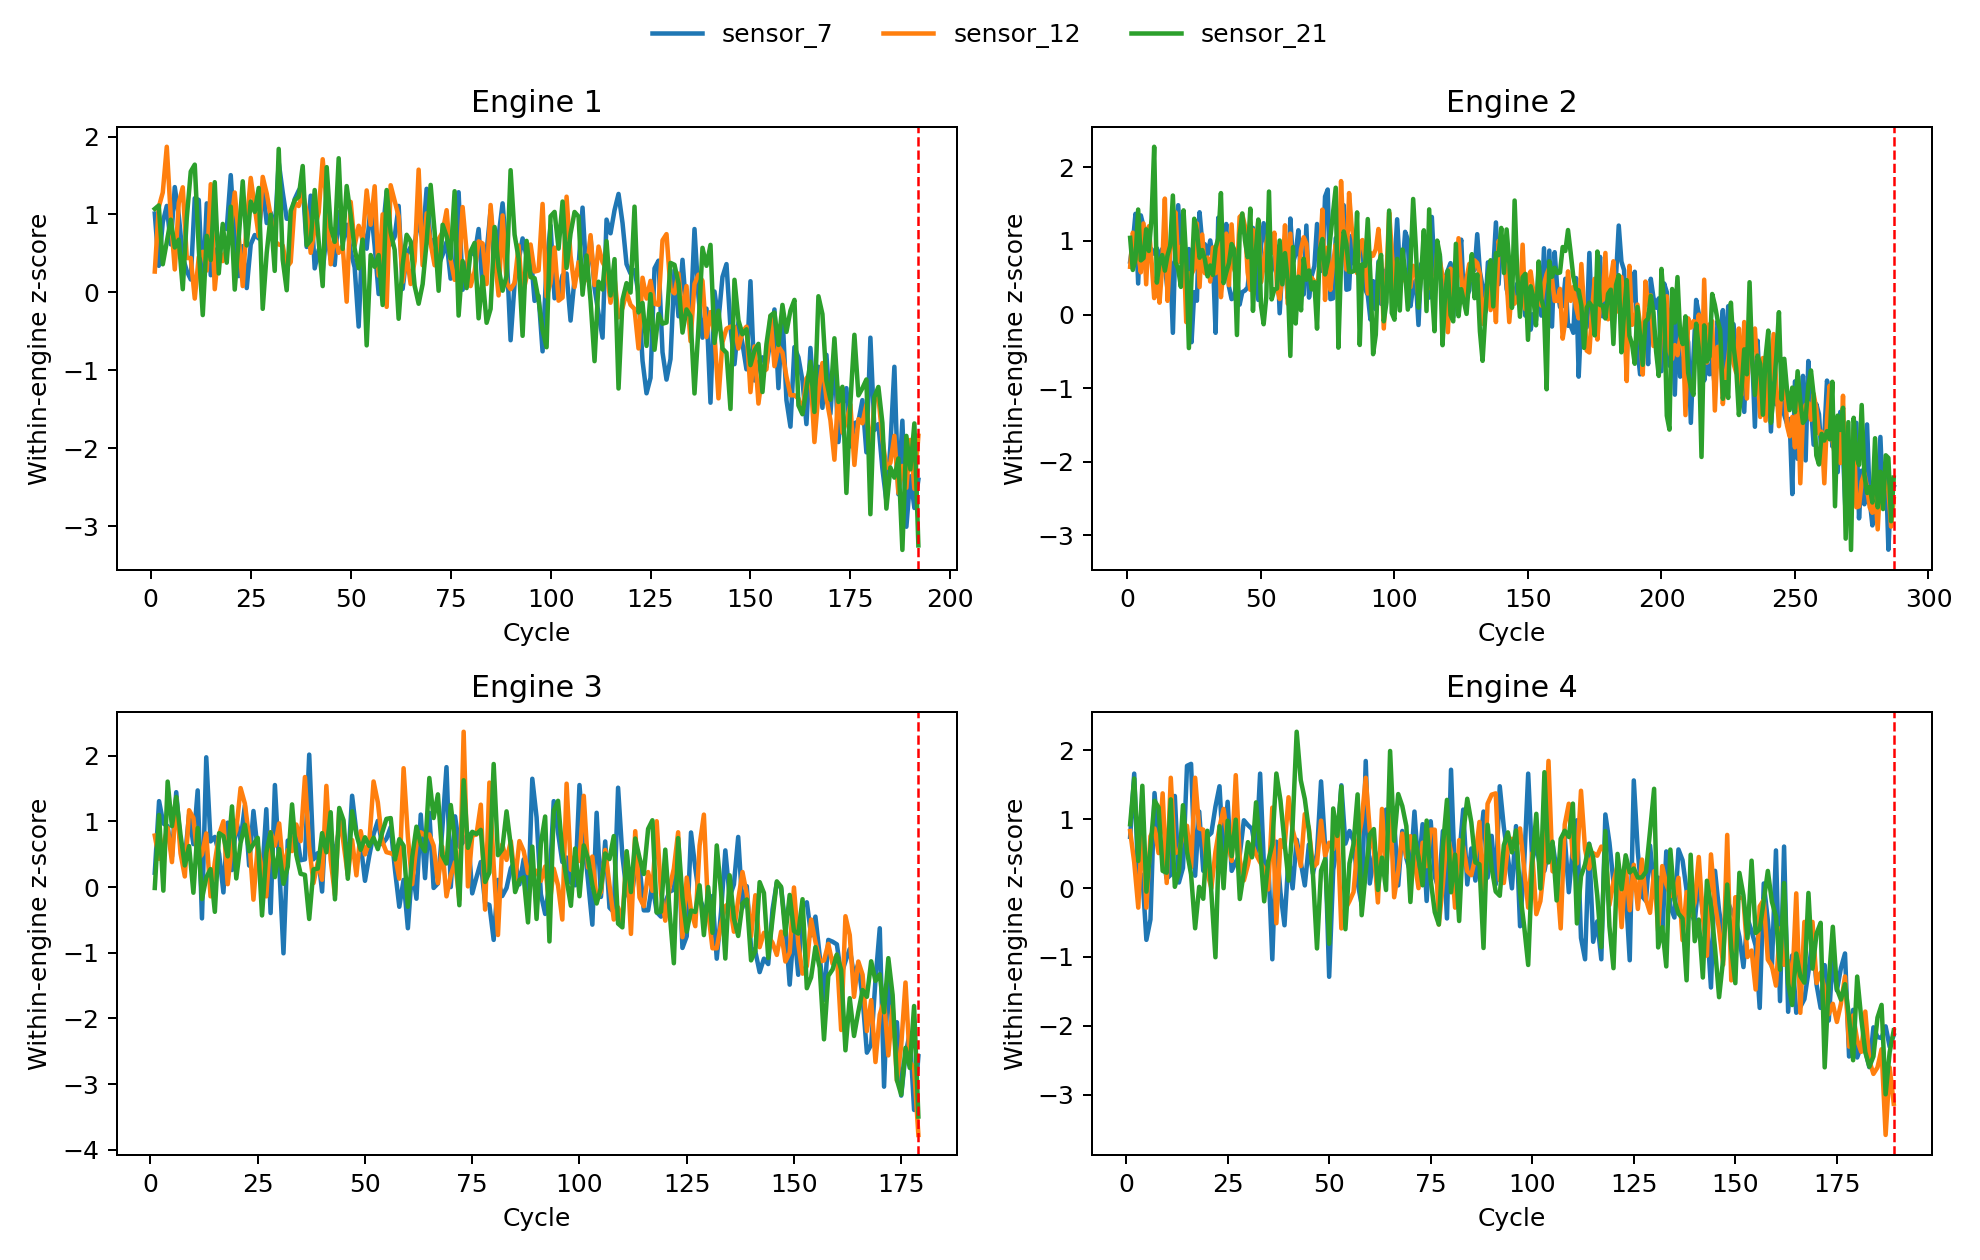

calibration_curve.png


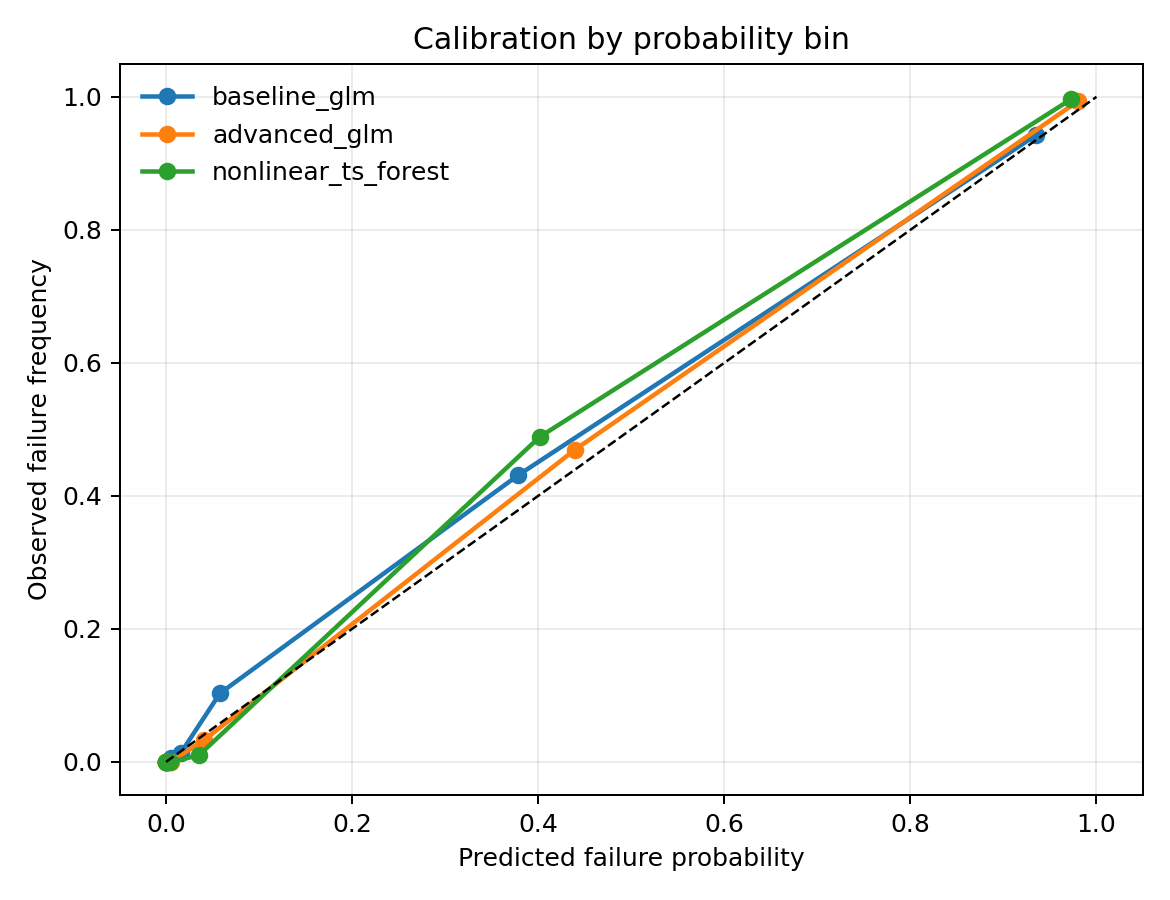

residual_acf.png


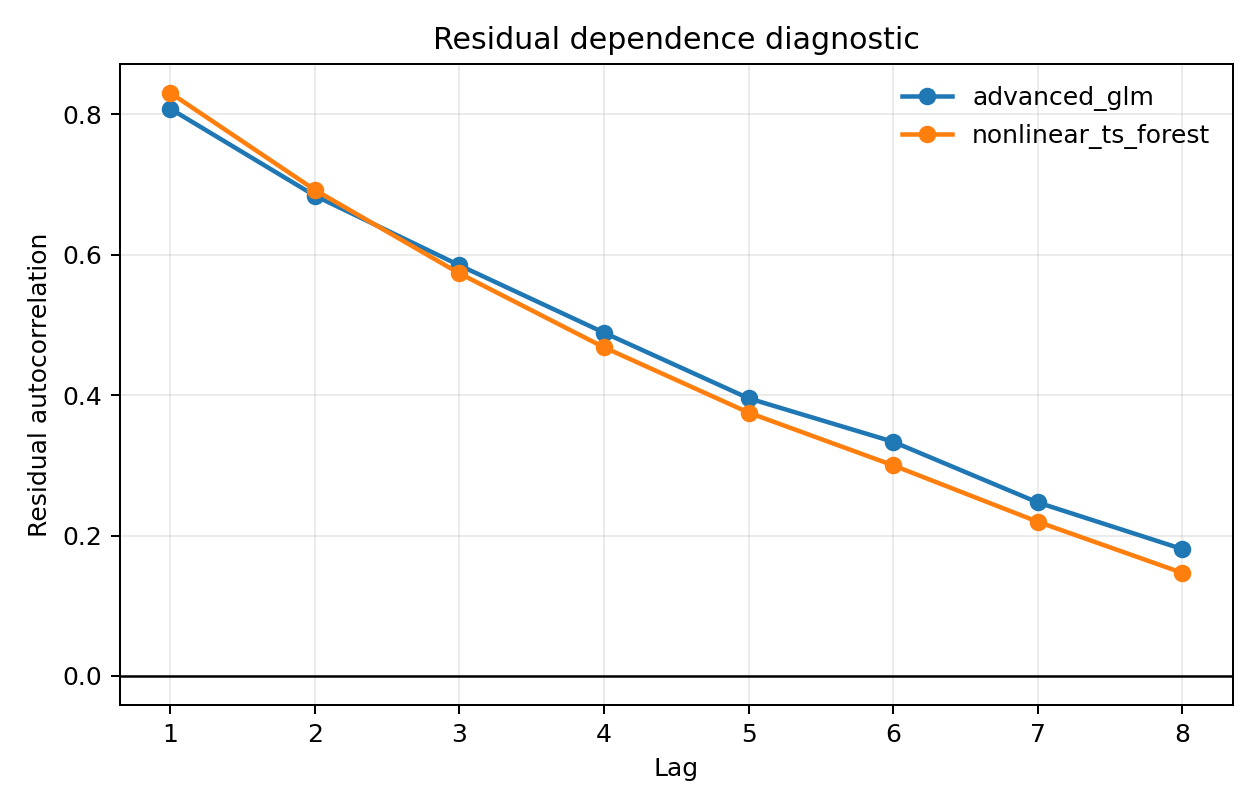

feature_importance_top10.png


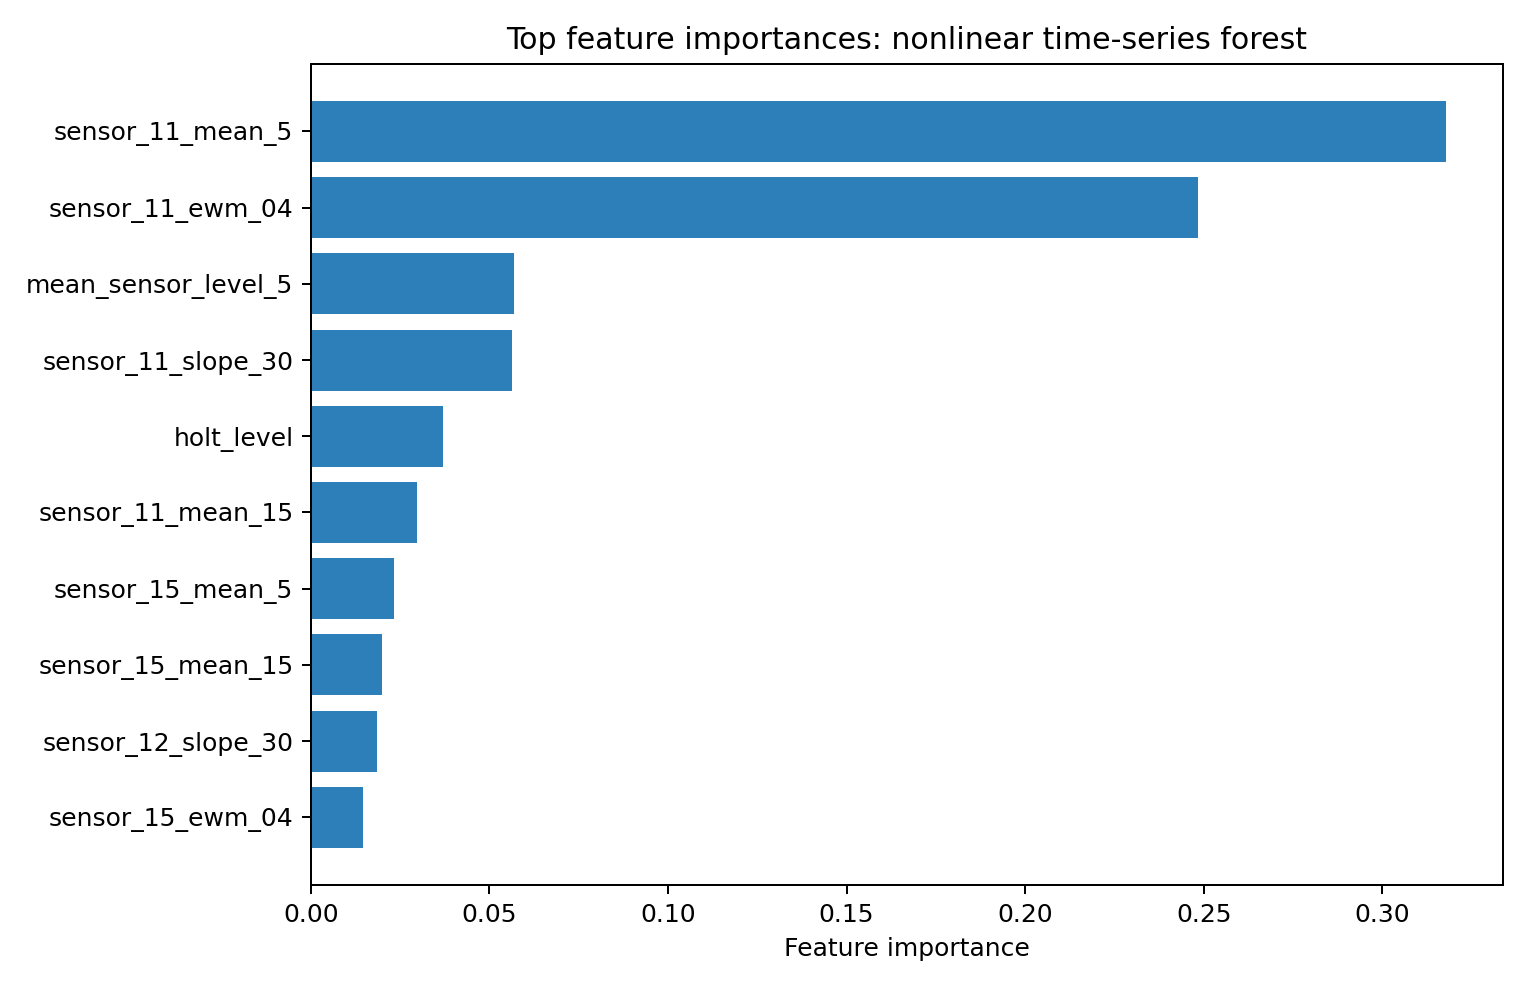

example_risk_path.png


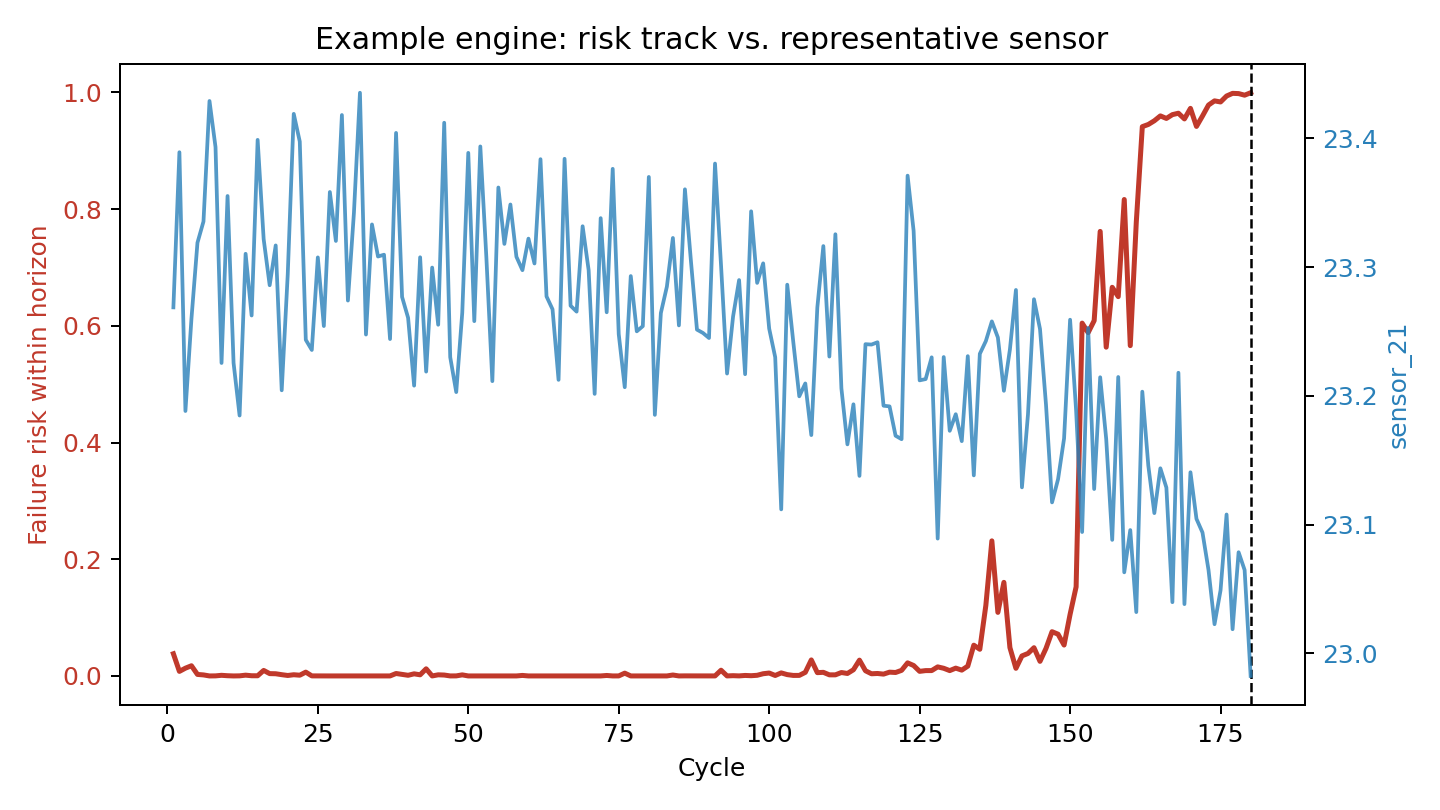

threshold_tuning_curve.png


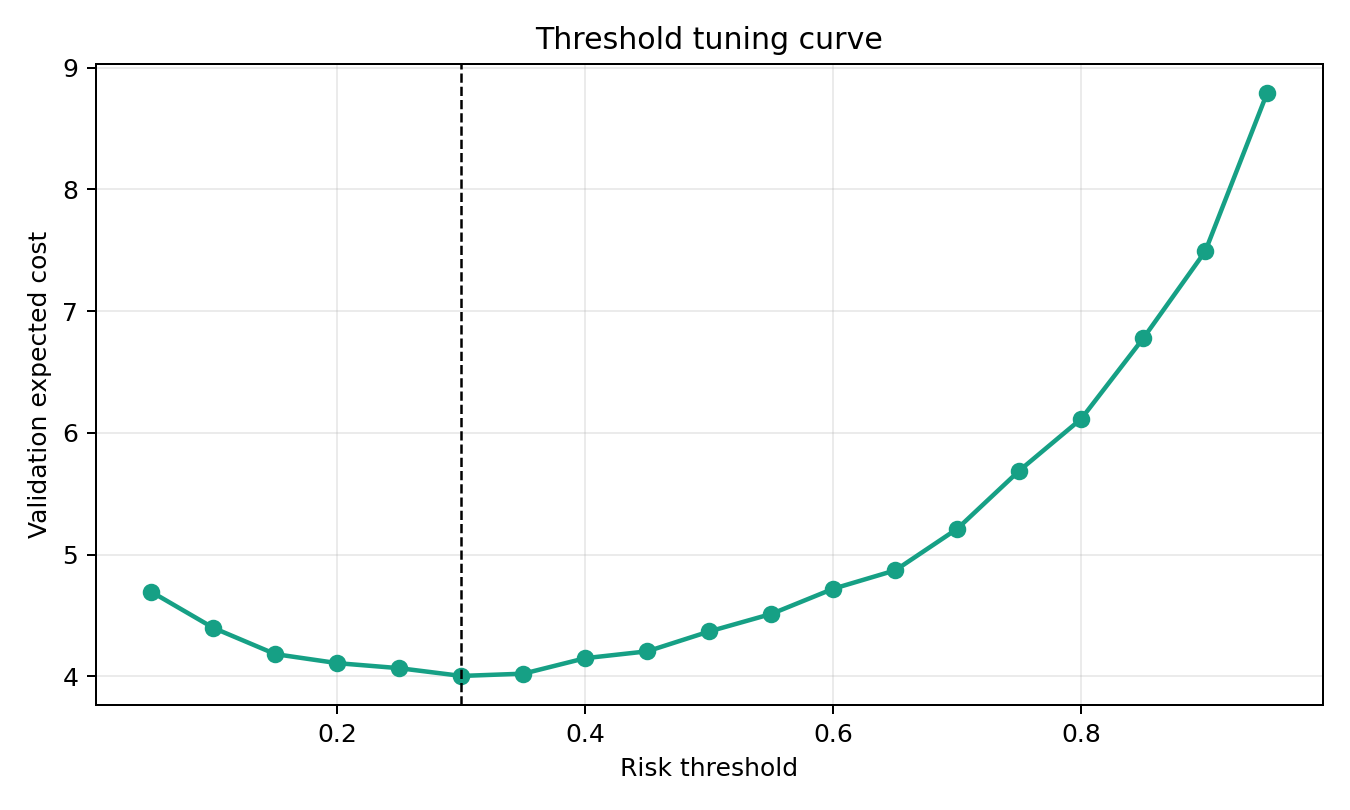

policy_comparison.png


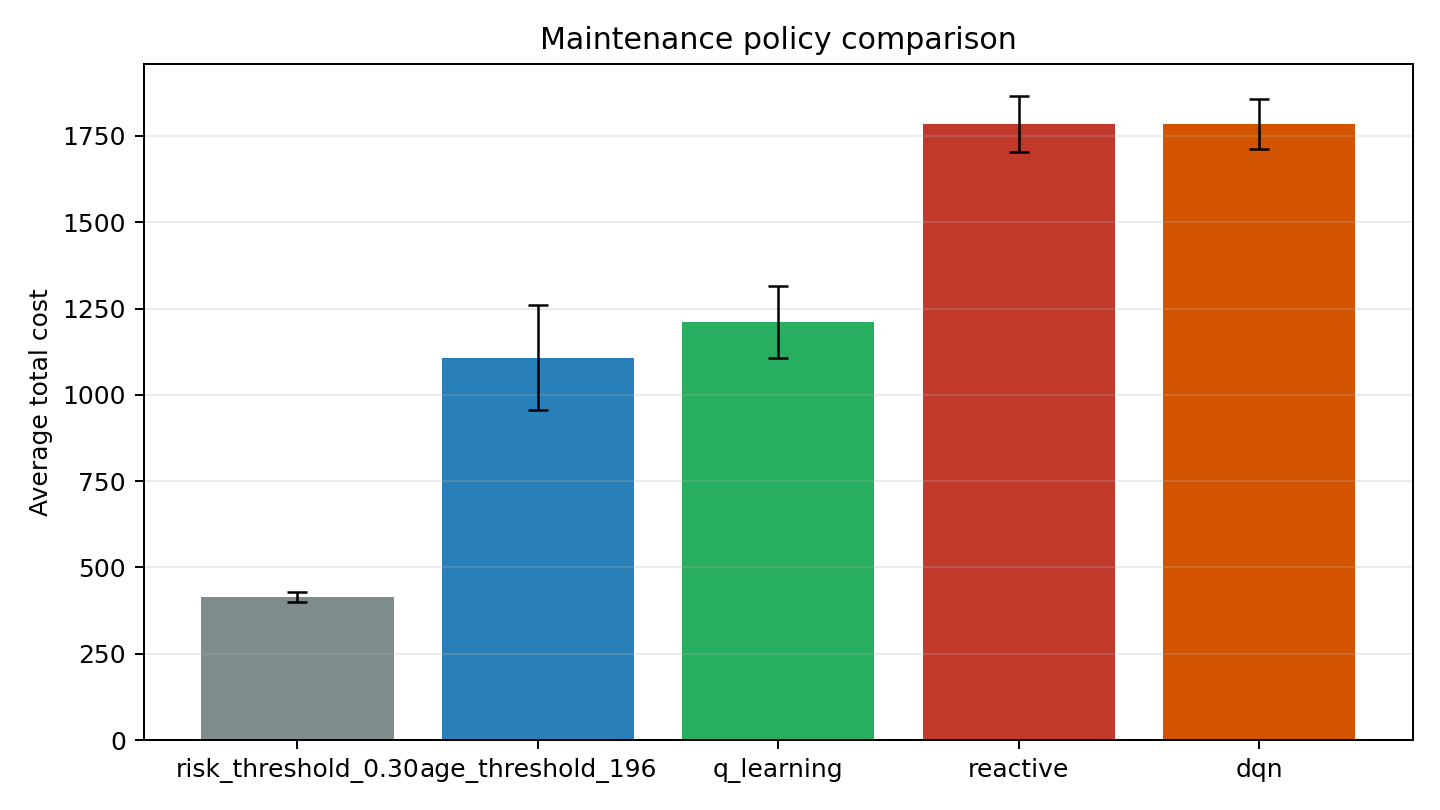

tree_tuning_curve.png


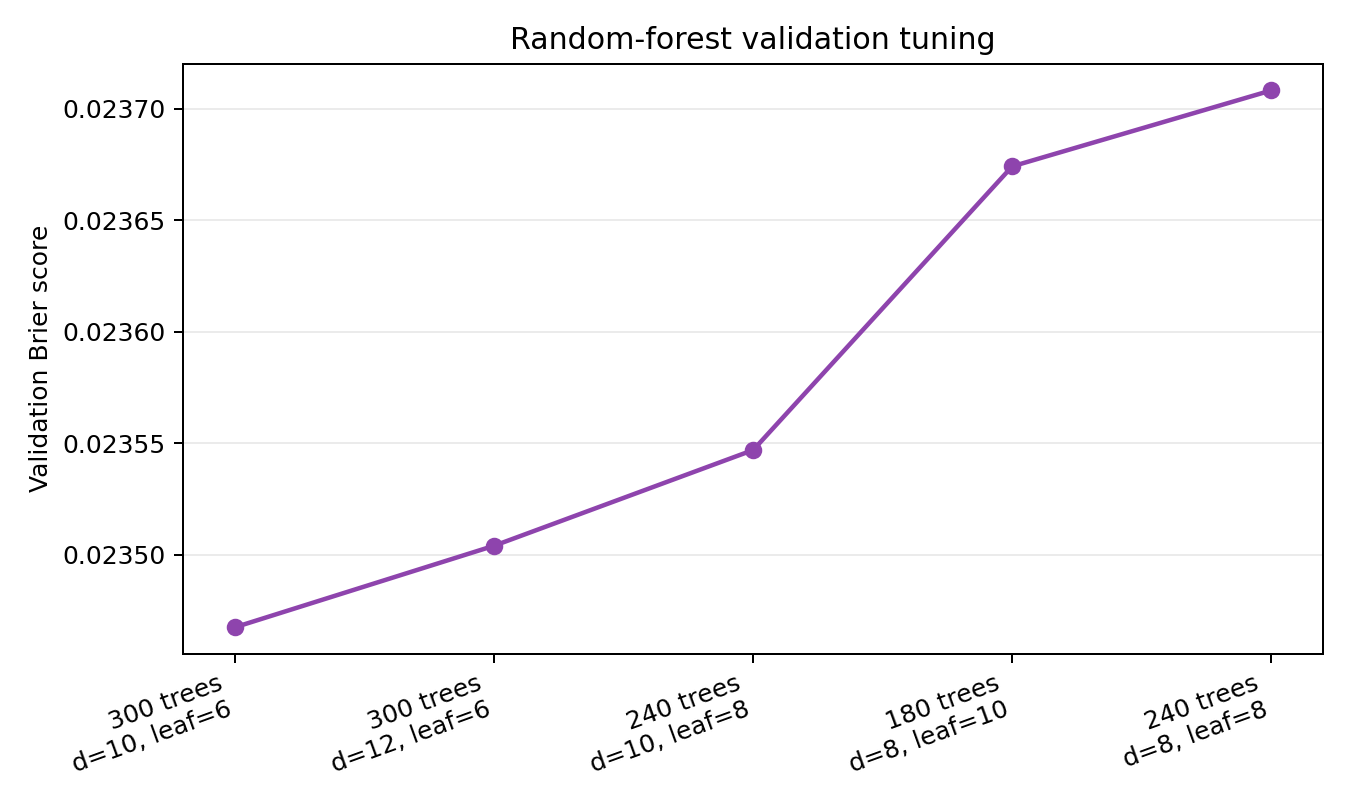

robustness_auc_by_subset.png


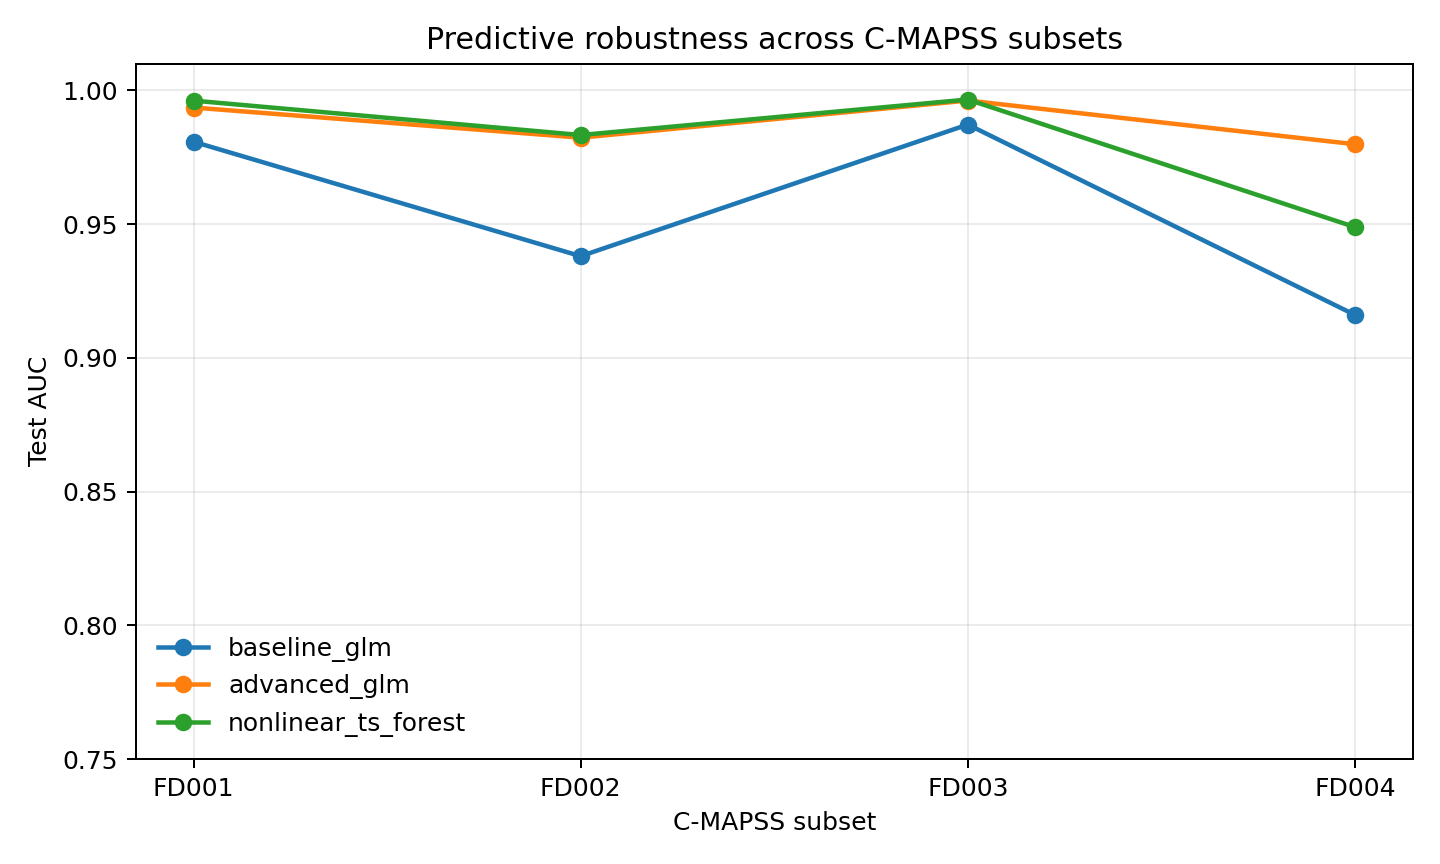

In [17]:
for name in [
    'example_trajectories.png',
    'calibration_curve.png',
    'residual_acf.png',
    'feature_importance_top10.png',
    'example_risk_path.png',
    'threshold_tuning_curve.png',
    'policy_comparison.png',
    'tree_tuning_curve.png',
    'robustness_auc_by_subset.png',
]:
    print(name)
    display(Image(filename=str(output_dir / name)))

## Final interpretation

The notebook supports the main project claim: when the comparison is framed as `snapshot-only` versus `time-series-aware` models, temporal summaries improve short-horizon failure prediction on FD001. The strongest predictive model is the nonlinear time-series forest, and the strongest maintenance policy is a simple tuned risk-threshold rule rather than a more complicated RL controller.